# Figure 2 — Marmosets update switching behavior based on reward history
Source: `_source_archive/by_figure/Fig2/05_Fig2_Reversal_v2.ipynb`.
Panel legends below are copied verbatim from the submitted/bioRxiv
manuscript (`2026.06.30.734629v1.full.pdf`).

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(".."))

from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.features.history_encoding import add_history_cols_marmoset, sort_animals
from src.behavior_metrics.transitions import classify_transitions
from src.behavior_metrics.criterion import trials_to_criterion, clean_ttc, aggregate_to_session
from src.behavior_metrics.late_accuracy import late_accuracy
from src.behavior_metrics.wsls import win_stay_lose_shift_by_session, summarize_pooled
from src.behavior_metrics.switch_by_history import switch_probability_by_history
from src.behavior_metrics import reversal_alignment as revalign
from src.plotting.style import apply_style
from src.plotting import fig2 as plotting
from src.plotting import reversal_alignment as revalign_plotting

config = load_config()
apply_style(config)
cfg = config["fig2"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig2")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {}


def show(path):
    display(SVG(path))

## Load data

In [2]:
df = load_snapshot(config, cfg["input_files"]["reversal_100_0"])
print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

Loaded 11,484 trials from 53 sessions, 6 animals


## Classify block transitions (cued vs. uncued)
Used by panels a, b, c.

In [3]:
trans_df = classify_transitions(df)
print(trans_df["transition_type"].value_counts())
manifest["n_transitions"] = {k: int(v) for k, v in trans_df["transition_type"].value_counts().items()}

transition_type
UNCUED    103
CUED       62
Name: count, dtype: int64


## Panel a
**Manuscript legend:** *"Schematic representation of task structure and
example showing blocks, ITIs and performance across one session. In the
visual discrimination with a reversal task, the probability of reward for
selecting one object (the correct choice) is 1 and 0 for other object
(the incorrect choice). The identity and location of the rewarded visual
object are held constant for a variable length of trials (a block)
before reversing the reward contingencies for the two stimuli. Following
a reversal block, the next block will be a cued transition where two new
visual stimuli will appear in two new locations on the touchscreen.
Blocks are predefined changes in the visual discrimination or reversal
rule; vertical lines indicate whether change is a 'cued transition'
(solid blue) or an uncued reversal (dashed orange). Performance is given
by the accuracy of selecting the high probability choice over a 5-trial
sliding window."*

The schematic illustration itself is not data-derived. The representative
session (data-derived half) is built here from the manuscript's own
exemplar-session code (`src/plotting/reversal_alignment.py::plot_exemplar_session`,
provided directly by the user, not reconstructed): block-alternating
2-color bar with block-number labels, choice-location scatter colored by
outcome, per-block-colored ITI and centered-rolling-accuracy traces.
Session picked as the first session with >150 trials, matching that same
source code's own selection rule.

Panel a example session: 2023-08-11_20230811_Knuckles_Reversal1.1 (283 trials)


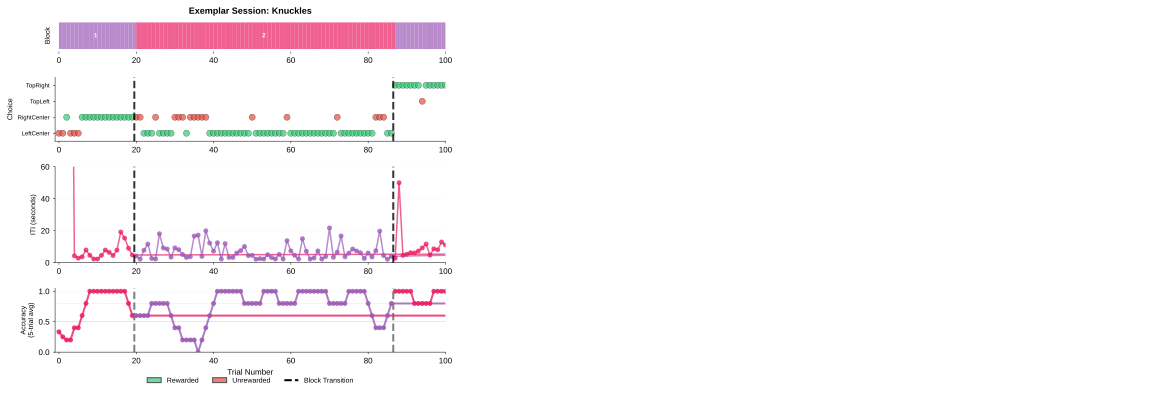

In [4]:
example_session_id = revalign.pick_representative_session(df)
session_data = df[df["Session_ID"] == example_session_id]
print(f"Panel a example session: {example_session_id} ({len(session_data)} trials)")
revalign_plotting.plot_exemplar_session(
    session_data, "Outcome", config, os.path.join(FIG_DIR, "representative_session.svg")
)
show(os.path.join(FIG_DIR, "representative_session.svg"))
manifest["representative_session_id"] = example_session_id

## Panel b
**Manuscript legend:** *"Probability of selecting the high probability
choice ('high-prob choice') at each trial position for either cued
transition (blue solid line) or uncued reversal (orange dashed). Shaded
error bars indicate standard error of mean."*

Built directly from the legend -- no source-notebook plotting cell
matches it (the underlying transition classification is the same
`classify_transitions` used elsewhere in this notebook).

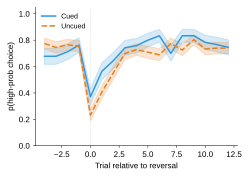

In [5]:
aligned_df = revalign.accuracy_by_position_relative_to_transition(
    df, trans_df, "Outcome", cfg["reversal_window_before"], cfg["reversal_window_after"]
)
position_summary = revalign.summarize_by_position(aligned_df, group_cols=["transition_type"])
revalign_plotting.plot_reversal_alignment(
    position_summary, config, os.path.join(FIG_DIR, "reversal_alignment.svg"), split_by_type=True
)
show(os.path.join(FIG_DIR, "reversal_alignment.svg"))
manifest["reversal_alignment"] = {
    f"{row['transition_type']}_{row['position']}": {"mean": float(row["mean"]), "sem": float(row["sem"]), "n": int(row["n"])}
    for _, row in position_summary.iterrows()
}

## Panel c
**Manuscript legend:** *"Trials to criterion (top, accuracy >= 0.8 across
5 trials) and the accuracy in the final 10 trials of a block (bottom,
'late accuracy') across all individual marmosets (bars) and sessions
(dots)."*

Reversals analyzed: 165, reached criterion: 154 (93.3%)


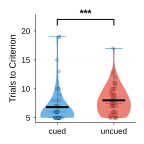

{'u_stat': np.float64(789.5), 'p_value': np.float64(0.00010051814836095352), 'cued_mean': np.float64(6.8307692307692305), 'cued_median': np.float64(6.0), 'cued_n': 52, 'uncued_mean': np.float64(8.009615384615385), 'uncued_median': np.float64(7.5), 'uncued_n': 52}


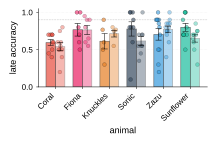

{'cued_mean': np.float64(0.7150326797385621), 'cued_sem': np.float64(0.03154778131459975), 'cued_n': 51, 'uncued_mean': np.float64(0.6720125786163522), 'uncued_sem': np.float64(0.02413548605284901), 'uncued_n': 53, 'wilcoxon_stat': np.float64(7.0), 'p_value': np.float64(0.5625)}


In [6]:
ttc_df = trials_to_criterion(
    df, trans_df, accuracy_col="Outcome",
    criterion_accuracy=cfg["criterion_accuracy"], criterion_window=cfg["criterion_window"],
)
ttc_clean = clean_ttc(ttc_df)
print(f"Reversals analyzed: {len(ttc_df)}, reached criterion: {len(ttc_clean)} "
      f"({len(ttc_clean)/len(ttc_df)*100:.1f}%)")

ttc_session = aggregate_to_session(ttc_clean, "trials_to_criterion", extra_group_cols=["transition_type"])
ttc_stats = plotting.plot_trials_to_criterion(
    ttc_session, config, os.path.join(FIG_DIR, "trials_to_criterion.svg")
)
show(os.path.join(FIG_DIR, "trials_to_criterion.svg"))
print(ttc_stats)
manifest["trials_to_criterion"] = {
    "cued_mean": float(ttc_stats["cued_mean"]), "cued_median": float(ttc_stats["cued_median"]), "cued_n": int(ttc_stats["cued_n"]),
    "uncued_mean": float(ttc_stats["uncued_mean"]), "uncued_median": float(ttc_stats["uncued_median"]), "uncued_n": int(ttc_stats["uncued_n"]),
    "mannwhitney_U": float(ttc_stats["u_stat"]), "p_value": float(ttc_stats["p_value"]),
}

late_acc_df = late_accuracy(df, trans_df, accuracy_col="Outcome", late_window=cfg["late_window"])
late_acc_session = aggregate_to_session(late_acc_df, "late_accuracy", extra_group_cols=["transition_type"])
late_stats = plotting.plot_late_accuracy(late_acc_session, config, os.path.join(FIG_DIR, "late_accuracy.svg"))
show(os.path.join(FIG_DIR, "late_accuracy.svg"))
print(late_stats)
manifest["late_accuracy"] = {k: (float(v) if hasattr(v, "__float__") else v) for k, v in late_stats.items()}

## Panel d
**Manuscript legend:** *"Probability of repeating after a reward
(win-stay) or switching after a loss (loss-switch) across all individual
marmosets (bars) and sessions (dots)."*

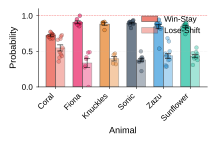

{'win_stay_mean': np.float64(0.8437388960042292), 'win_stay_sem': np.float64(0.011774765358642804), 'lose_shift_mean': np.float64(0.4299147356740607), 'lose_shift_sem': np.float64(0.017573203490549305), 'n_sessions_win': 53, 'n_sessions_lose': 53}


In [7]:
wsls_sessions = win_stay_lose_shift_by_session(df)
pooled_wsls = summarize_pooled(wsls_sessions)
plotting.plot_wsls(wsls_sessions, pooled_wsls, config, os.path.join(FIG_DIR, "wsls.svg"))
show(os.path.join(FIG_DIR, "wsls.svg"))
print(pooled_wsls)
manifest["win_stay_lose_shift"] = {k: float(v) for k, v in pooled_wsls.items()}

## Panel e
**Manuscript legend:** *"Probability of switching conditioned on the
three previous outcomes (rewarded = 1, unrewarded = 0) where the most
recent outcome is the final number of the sequence, averaged across all
marmosets (black line) superimposed on top of individual marmosets
(colored lines)."*

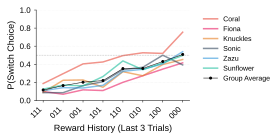

  reward_seq  p_switch       sem  n_animals  n_trials
7        111  0.115570  0.015335          6      6148
3        011  0.163950  0.034965          6       949
1        001  0.201553  0.043194          6       780
5        101  0.219591  0.046535          6       427
6        110  0.351992  0.042099          6       957
2        010  0.353877  0.038127          6       266
4        100  0.430577  0.027039          6       793
0        000  0.508614  0.053838          6      1005


In [8]:
df["test_choice"] = df["StimuliChosen"].map({"TargetA": 1, "TargetB": 0})
df["test_outcome"] = df["Reward"].map({"Rewarded": 1, "Unrewarded": 0})
df_hist = add_history_cols_marmoset(df, cfg["history_n"])
per_animal, overall = switch_probability_by_history(df_hist)
plotting.plot_switch_by_history(per_animal, overall, config, os.path.join(FIG_DIR, "switch_by_history.svg"))
show(os.path.join(FIG_DIR, "switch_by_history.svg"))
print(overall)
manifest["switch_by_history"] = overall.set_index("reward_seq")[["p_switch", "sem", "n_animals", "n_trials"]].to_dict(orient="index")

## Values manifest

In [9]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig2.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/Fig2.json
